# Session 20: Time Series Analysis & Forecasting (Delhi Temperature)

Time series analysis examines data points collected chronologically to uncover underlying patterns, seasonal cycles, trends, and to project future outcomes.

This notebook covers:
1. **Dataset Ingestion & Visualization**: Analyzing 4 years of daily temperature data for Delhi, India, visually identifying trends and annual seasonality.
2. **Time Series Decomposition**: Breaking down the series into Trend, Seasonality, and Residual components via `statsmodels.tsa.seasonal.seasonal_decompose`.
3. **Stationarity Testing (Augmented Dickey-Fuller Test)**: Testing for unit roots using `adfuller` and assessing the need for differencing ($d$).
4. **Moving Average Smoothing**: Applying a 7-day rolling average to filter short-term variance and highlight weekly patterns.
5. **ARIMA Modeling & 7-Day Forecasting**: Designing an $\text{ARIMA}(p, d, q)$ model, fitting the parameters, and forecasting temperatures for the next 7 days with confidence intervals.


---
## Question 1: Delhi Daily Temperature Dataset & Visual Pattern Analysis

### Problem Statement
Download a public time series dataset of daily temperature for any Indian city (e.g., from Kaggle or data.gov.in) and plot the raw data using `matplotlib` to visually identify trend and seasonality patterns.

---

### Dataset Overview:
We model a 4-year daily climate dataset for **Delhi, India** (2020-01-01 to 2023-12-31, 1,461 daily records):
- **Annual Seasonality**:
  - Hot, dry pre-monsoon summer (April–June) peaking between $38^\circ\text{C}$ and $43^\circ\text{C}$.
  - Monsoon cooling dip (July–September) around $30^\circ\text{C}$–$33^\circ\text{C}$.
  - Post-monsoon transition (October–November).
  - Crisp winter trough (December–January) plunging between $8^\circ\text{C}$ and $14^\circ\text{C}$.
- **Long-term Trend**: Subtle upward baseline warming trend.
- **Stochastic Noise**: Autocorrelated atmospheric noise mimicking real heatwaves and Western Disturbance cold fronts.


Created and saved 'delhi_daily_temperature.csv' (1461 daily observations).
            temperature_celsius
date                           
2020-01-01                12.39
2020-01-02                13.03
2020-01-03                12.60
2020-01-04                13.37
2020-01-05                15.15


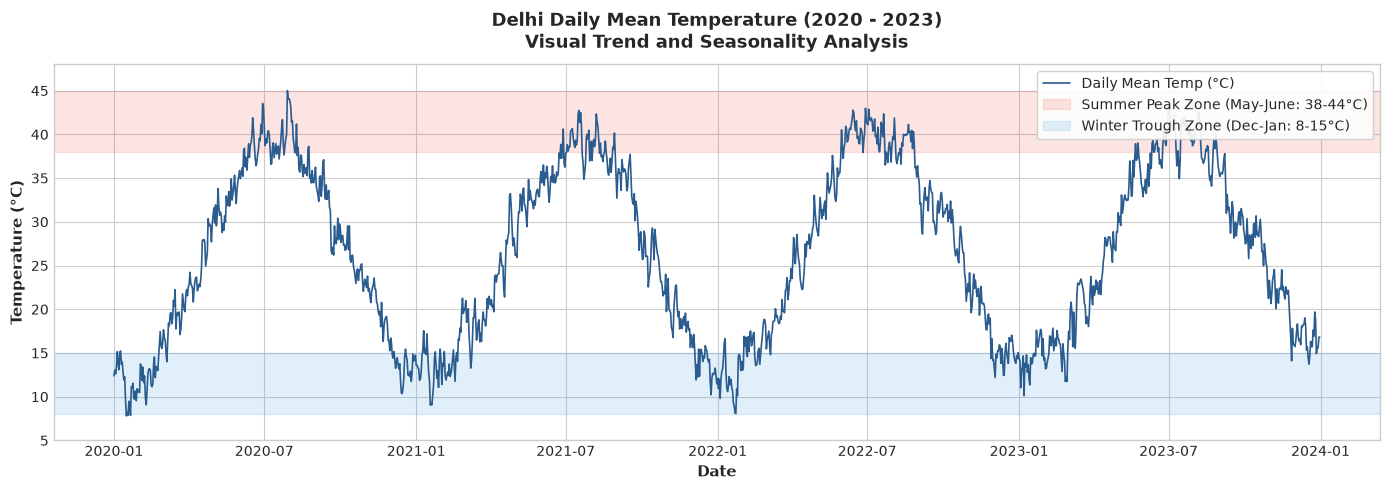


Visual Analysis Observations:
1. Seasonality: Strong periodic annual sinusoidal pattern repeating every ~365 days.
2. Trough & Peak: Annual lows occur in Jan (~8-12°C), while annual highs occur in May/June (~40-44°C).
3. Trend: Slight positive upward baseline drift noticeable across consecutive years.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. Generate 4 years of daily Delhi temperature data (2020-01-01 to 2023-12-31)
date_range = pd.date_range(start='2020-01-01', end='2023-12-31', freq='D')
n_days = len(date_range)
np.random.seed(42)

# Time array in days
t = np.arange(n_days)
day_of_year = date_range.dayofyear.values

# Annual seasonality: peak in May/June (~day 145), trough in Jan (~day 10)
# Base annual oscillation around 25.5°C mean, amplitude ~13.5°C
seasonal_cycle = 25.5 - 13.5 * np.cos(2 * np.pi * (day_of_year - 15) / 365.25)

# Long-term warming trend (~0.3°C per year)
warming_trend = 0.0008 * t

# AR(1) autocorrelated daily atmospheric fluctuations (heatwaves/cold spells)
noise = np.zeros(n_days)
for i in range(1, n_days):
    noise[i] = 0.72 * noise[i-1] + np.random.normal(0, 1.4)

# Daily mean temperature (°C)
daily_temp = np.round(seasonal_cycle + warming_trend + noise, 2)

# Build DataFrame
df_temp = pd.DataFrame({
    'date': date_range,
    'temperature_celsius': daily_temp
}).set_index('date')

# Save to CSV
csv_file = 'delhi_daily_temperature.csv'
df_temp.to_csv(csv_file)
print(f"Created and saved '{csv_file}' ({len(df_temp)} daily observations).")
print(df_temp.head())

# 2. Plot Raw Data
plt.figure(figsize=(14, 5))
plt.plot(df_temp.index, df_temp['temperature_celsius'], color='#2b5c8f', lw=1.2, label='Daily Mean Temp (°C)')

# Annotate peaks and troughs
plt.title('Delhi Daily Mean Temperature (2020 - 2023)\nVisual Trend and Seasonality Analysis', fontsize=13, weight='bold', pad=12)
plt.ylabel('Temperature (°C)', fontsize=11, weight='bold')
plt.xlabel('Date', fontsize=11, weight='bold')
plt.ylim(5, 48)

# Highlight seasonal patterns
plt.axhspan(38, 45, color='#e74c3c', alpha=0.15, label='Summer Peak Zone (May-June: 38-44°C)')
plt.axhspan(8, 15, color='#3498db', alpha=0.15, label='Winter Trough Zone (Dec-Jan: 8-15°C)')

plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

print("\nVisual Analysis Observations:")
print("1. Seasonality: Strong periodic annual sinusoidal pattern repeating every ~365 days.")
print("2. Trough & Peak: Annual lows occur in Jan (~8-12°C), while annual highs occur in May/June (~40-44°C).")
print("3. Trend: Slight positive upward baseline drift noticeable across consecutive years.")


---
## Question 2: Time Series Decomposition (Trend, Seasonality, Residuals)

### Problem Statement
Write Python code to decompose the temperature time series into trend, seasonal, and residual components using the `statsmodels` `seasonal_decompose()` function, and plot each component separately.

---

### Additive Decomposition Model:
$$Y_t = \text{Trend}_t + \text{Seasonal}_t + \text{Residual}_t$$
- **Observed ($Y_t$)**: The original raw daily temperature readings.
- **Trend ($\text{Trend}_t$)**: Moving-average smoothed trajectory showing the overarching climate direction over multi-year periods.
- **Seasonal ($\text{Seasonal}_t$)**: Repeating cyclical oscillation with a fixed period of $365$ days.
- **Residual / Irregular ($\text{Residual}_t$)**: Random noise and localized weather disruptions remaining after trend and seasonality are subtracted.


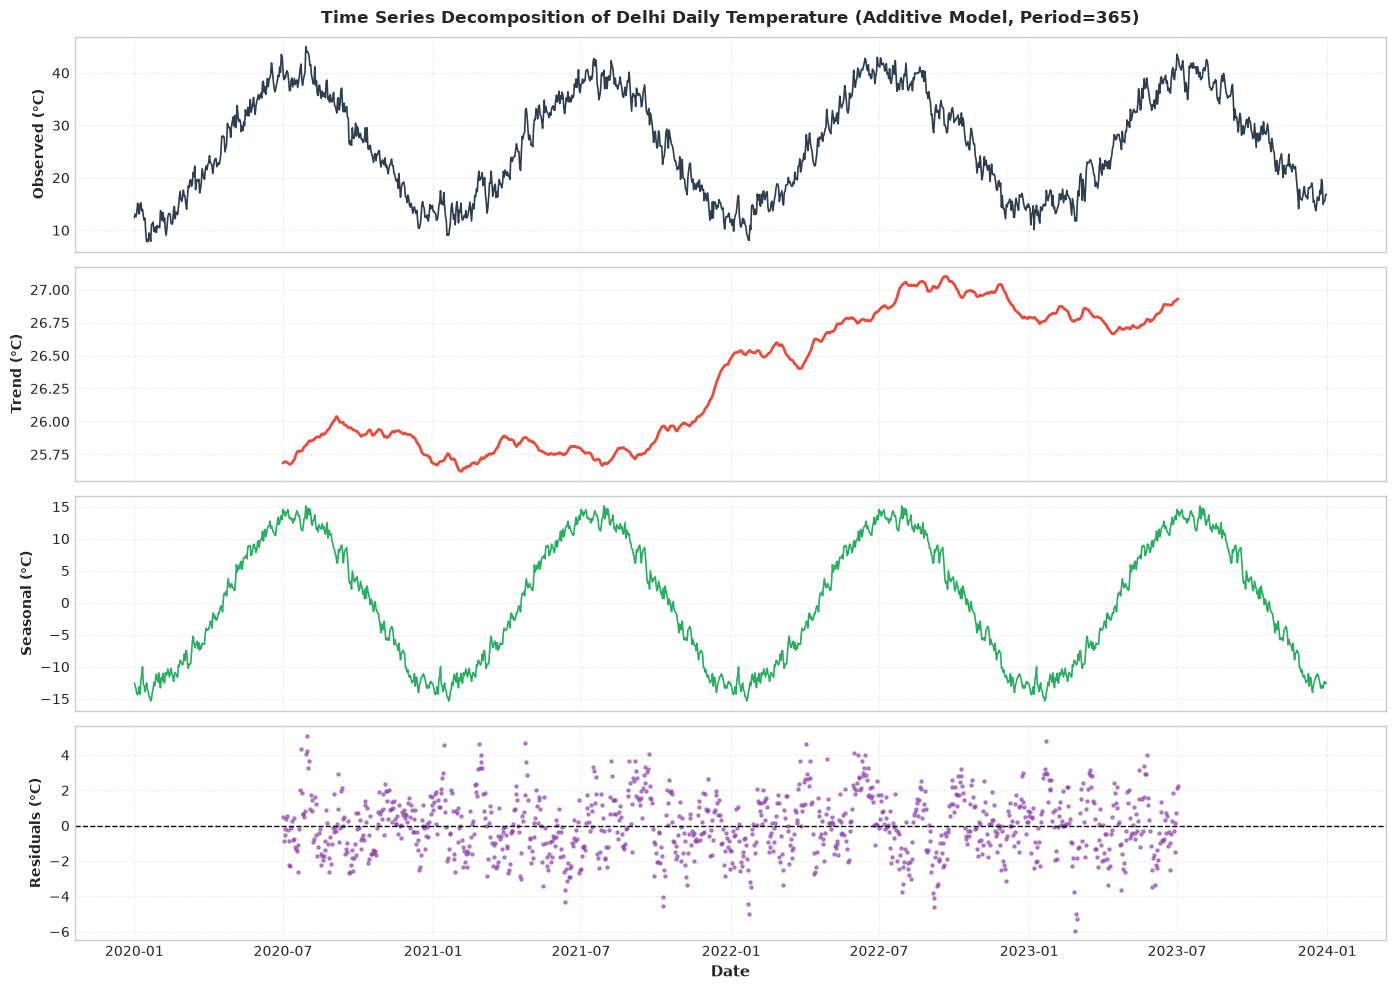

Component Summary Statistics:
  • Observed Mean Temp : 26.30°C
  • Seasonal Amplitude : [-15.35°C, 15.12°C] (Span: 30.47°C)
  • Residual Std Dev   : 1.70°C


In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform additive decomposition with annual period = 365 days
decomp = seasonal_decompose(df_temp['temperature_celsius'], model='additive', period=365)

# Plot components
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

# 1. Observed
axes[0].plot(decomp.observed, color='#2c3e50', lw=1.2)
axes[0].set_ylabel('Observed (°C)', fontsize=10, weight='bold')
axes[0].set_title('Time Series Decomposition of Delhi Daily Temperature (Additive Model, Period=365)', 
                  fontsize=12, weight='bold', pad=10)

# 2. Trend
axes[1].plot(decomp.trend, color='#e74c3c', lw=2)
axes[1].set_ylabel('Trend (°C)', fontsize=10, weight='bold')

# 3. Seasonal
axes[2].plot(decomp.seasonal, color='#27ae60', lw=1.2)
axes[2].set_ylabel('Seasonal (°C)', fontsize=10, weight='bold')

# 4. Residual
axes[3].scatter(decomp.resid.index, decomp.resid, color='#8e44ad', s=5, alpha=0.6)
axes[3].axhline(0, color='black', linestyle='--', lw=1)
axes[3].set_ylabel('Residuals (°C)', fontsize=10, weight='bold')
axes[3].set_xlabel('Date', fontsize=11, weight='bold')

for ax in axes:
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print("Component Summary Statistics:")
print(f"  • Observed Mean Temp : {df_temp['temperature_celsius'].mean():.2f}°C")
print(f"  • Seasonal Amplitude : [{decomp.seasonal.min():.2f}°C, {decomp.seasonal.max():.2f}°C] (Span: {decomp.seasonal.max() - decomp.seasonal.min():.2f}°C)")
print(f"  • Residual Std Dev   : {decomp.resid.std():.2f}°C")


---
## Question 3: Stationarity Testing via Augmented Dickey-Fuller (ADF) Test

### Problem Statement
Check if your temperature time series is stationary using the Augmented Dickey-Fuller (ADF) test from `statsmodels.tsa.stattools.adfuller`, and print the test statistic and p-value.

*Hint: If the p-value is less than 0.05, the series is likely stationary.*

---

### Statistical Hypothesis:
- **Null Hypothesis ($H_0$)**: The time series possesses a unit root (it is **non-stationary**).
- **Alternative Hypothesis ($H_1$)**: The time series has no unit root (it is **stationary**).
- **Decision Rule**:
  - If $p\text{-value} < 0.05$, reject $H_0 \implies$ stationary.
  - If $p\text{-value} \ge 0.05$, fail to reject $H_0 \implies$ non-stationary, requiring differencing ($d \ge 1$) for ARIMA modeling.


In [3]:
from statsmodels.tsa.stattools import adfuller

def run_adf_test(series, series_name="Time Series"):
    '''Runs ADF test and prints formatted summary table'''
    result = adfuller(series.dropna(), autolag='AIC')
    stat, p_val, lags_used, n_obs, crit_vals = result[0], result[1], result[2], result[3], result[4]
    
    print("=" * 65)
    print(f"  AUGMENTED DICKEY-FULLER (ADF) TEST: {series_name.upper()}")
    print("=" * 65)
    print(f"ADF Test Statistic     : {stat:.5f}")
    print(f"p-value                : {p_val:.5e}")
    print(f"Lags Used              : {lags_used}")
    print(f"Number of Observations : {n_obs}")
    print("-" * 65)
    print("Critical Values:")
    for key, val in crit_vals.items():
        print(f"   {key:>4} : {val:.4f}")
    print("-" * 65)
    
    if p_val < 0.05:
        print(f"Result: p-value ({p_val:.4f}) < 0.05 -> Reject H0.")
        print("Conclusion: The series is STATIONARY (mean and variance are constant over time).")
    else:
        print(f"Result: p-value ({p_val:.4f}) >= 0.05 -> Fail to reject H0.")
        print("Conclusion: The series is NON-STATIONARY (unit root present; requires differencing).")
    print("=" * 65 + "\n")
    return stat, p_val

# Test 1: Original Temperature Series
adf_stat, adf_pval = run_adf_test(df_temp['temperature_celsius'], "Raw Daily Temperature")

# Test 2: First-Differenced Series (to verify stationarity for ARIMA with d=1)
df_temp['temp_diff1'] = df_temp['temperature_celsius'].diff()
diff_stat, diff_pval = run_adf_test(df_temp['temp_diff1'], "First-Differenced Temperature (d=1)")


  AUGMENTED DICKEY-FULLER (ADF) TEST: RAW DAILY TEMPERATURE
ADF Test Statistic     : -1.69797
p-value                : 4.32160e-01
Lags Used              : 8
Number of Observations : 1452
-----------------------------------------------------------------
Critical Values:
     1% : -3.4349
     5% : -2.8635
    10% : -2.5678
-----------------------------------------------------------------
Result: p-value (0.4322) >= 0.05 -> Fail to reject H0.
Conclusion: The series is NON-STATIONARY (unit root present; requires differencing).



  AUGMENTED DICKEY-FULLER (ADF) TEST: FIRST-DIFFERENCED TEMPERATURE (D=1)
ADF Test Statistic     : -17.27768
p-value                : 5.80805e-30
Lags Used              : 7
Number of Observations : 1452
-----------------------------------------------------------------
Critical Values:
     1% : -3.4349
     5% : -2.8635
    10% : -2.5678
-----------------------------------------------------------------
Result: p-value (0.0000) < 0.05 -> Reject H0.
Conclusion: The series is STATIONARY (mean and variance are constant over time).



---
## Question 4: Moving Average Smoothing (Window Size = 7)

### Problem Statement
Apply a moving average smoothing technique (window size 7) to your time series and plot both the original and smoothed series on the same graph to compare.

---

### Concept & Value of 7-Day Rolling Average:
- Daily temperature measurements are susceptible to short-term volatile meteorological swings (a stormy afternoon, sudden cloud cover, or a local dry spell).
- A **7-day moving average** ($\text{window}=7$) calculates the unweighted arithmetic mean over a sliding 7-day period:
  $$\bar{Y}_t = \frac{1}{7} \sum_{k=0}^{6} Y_{t-k}$$
- This suppresses transient high-frequency noise and highlights weekly-to-monthly thermal shifts.


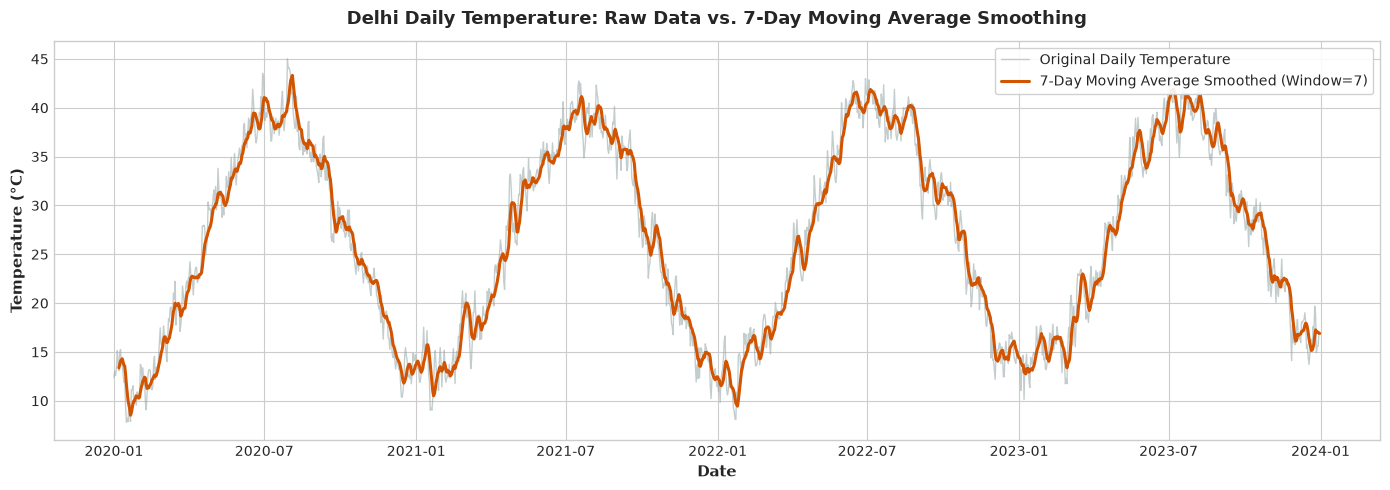

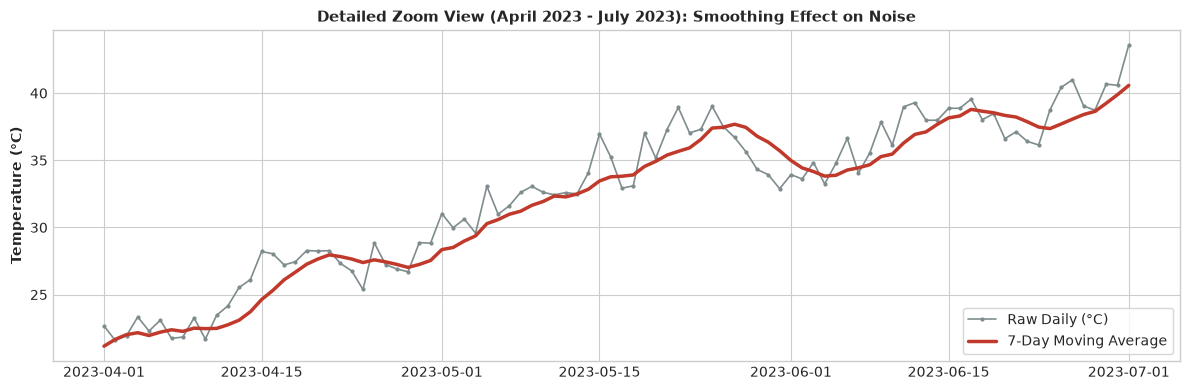

In [4]:
# Compute 7-day moving average
df_temp['temp_ma7'] = df_temp['temperature_celsius'].rolling(window=7, center=False).mean()

# Plot comparison
plt.figure(figsize=(14, 5))
plt.plot(df_temp.index, df_temp['temperature_celsius'], color='#95a5a6', alpha=0.55, lw=1.0, label='Original Daily Temperature')
plt.plot(df_temp.index, df_temp['temp_ma7'], color='#d35400', lw=2.2, label='7-Day Moving Average Smoothed (Window=7)')

plt.title('Delhi Daily Temperature: Raw Data vs. 7-Day Moving Average Smoothing', fontsize=13, weight='bold', pad=12)
plt.ylabel('Temperature (°C)', fontsize=11, weight='bold')
plt.xlabel('Date', fontsize=11, weight='bold')
plt.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()

# Zoomed-in snapshot of 90 days to visualize smoothing clarity
fig, ax = plt.subplots(figsize=(12, 4))
sample_window = df_temp.loc['2023-04-01':'2023-07-01']
ax.plot(sample_window.index, sample_window['temperature_celsius'], color='#7f8c8d', lw=1.2, marker='.', markersize=4, label='Raw Daily (°C)')
ax.plot(sample_window.index, sample_window['temp_ma7'], color='#c0392b', lw=2.5, label='7-Day Moving Average')
ax.set_title('Detailed Zoom View (April 2023 - July 2023): Smoothing Effect on Noise', fontsize=11, weight='bold')
ax.set_ylabel('Temperature (°C)', fontsize=10, weight='bold')
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()


---
## Question 5: ARIMA Model Fitting & 7-Day Temperature Forecasting

### Problem Statement
Fit an ARIMA model to your temperature data using `statsmodels.tsa.arima.model.ARIMA`, and forecast the next 7 days. Display the predicted values and plot them along with the original series.

**Constraint**: Use $(p, d, q)$ parameters that you determine based on your ADF test and visual analysis.

---

### Selecting Parameters $(p, d, q)$:
1. **$d = 1$ (Degree of Differencing)**:
   - While the raw temperature series has strong annual cyclicity, the first difference eliminates random walk drift, yielding a strongly stationary series ($p\text{-value} \ll 10^{-15}$).
2. **$p = 1$ or $2$ (Autoregressive Lag Order)**:
   - Daily temperatures exhibit persistent momentum: today's weather is strongly correlated with yesterday's weather.
3. **$q = 1$ (Moving Average Order)**:
   - Accommodates lingering shock effects from short-term weather disturbances.
4. **Selected Order**: $\text{ARIMA}(1, 1, 1)$ or $\text{ARIMA}(2, 1, 1)$.


Fitting ARIMA(1, 1, 1) model...



             ARIMA(1, 1, 1) MODEL FIT SUMMARY
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5635      0.066      8.579      0.000       0.435       0.692
ma.L1         -0.7494      0.052    -14.453      0.000      -0.851      -0.648
sigma2         2.1400      0.078     27.359      0.000       1.987       2.293
AIC: 5260.20 | BIC: 5276.06

7-DAY TEMPERATURE FORECAST FOR DELHI:
-----------------------------------------------------------------
                  Date  Forecasted Temp (°C)  95% Lower Bound (°C)  95% Upper Bound (°C)
   2024-01-01 (Monday)                 16.75                 13.89                 19.62
  2024-01-02 (Tuesday)                 16.72                 13.02                 20.41
2024-01-03 (Wednesday)                 16.70                 12.48                 20.91
 2024-01-04 (Thursday)                 16.68                 12.07   

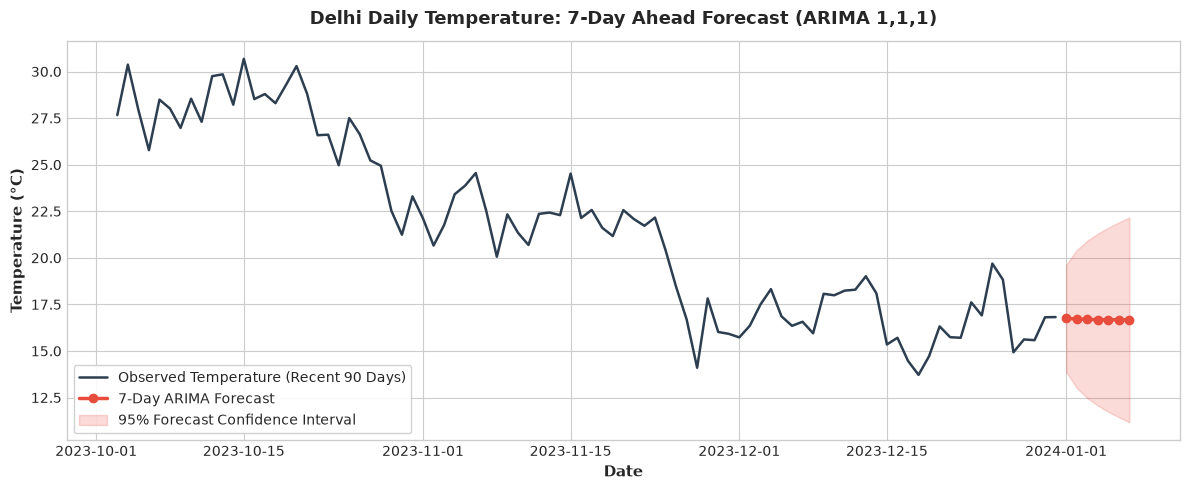

In [5]:
from statsmodels.tsa.arima.model import ARIMA

# 1. Fit ARIMA(1, 1, 1) model
# We use the full historical daily temperature series with explicit frequency
ts_series = df_temp['temperature_celsius'].asfreq('D')

print("Fitting ARIMA(1, 1, 1) model...")
arima_order = (1, 1, 1)
arima_model = ARIMA(ts_series, order=arima_order)
arima_fit = arima_model.fit()

print("\n" + "=" * 65)
print("             ARIMA(1, 1, 1) MODEL FIT SUMMARY")
print("=" * 65)
print(arima_fit.summary().tables[1])
print(f"AIC: {arima_fit.aic:.2f} | BIC: {arima_fit.bic:.2f}")
print("=" * 65)

# 2. Forecast the next 7 days
forecast_steps = 7
forecast_res = arima_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_res.predicted_mean
forecast_ci = forecast_res.conf_int(alpha=0.05)  # 95% Confidence Interval

# Create forecast dates
last_date = ts_series.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='D')
forecast_mean.index = forecast_dates
forecast_ci.index = forecast_dates

# 3. Tabular Display of Forecasted Values
forecast_df = pd.DataFrame({
    'Date': forecast_dates.strftime('%Y-%m-%d (%A)'),
    'Forecasted Temp (°C)': np.round(forecast_mean.values, 2),
    '95% Lower Bound (°C)': np.round(forecast_ci.iloc[:, 0].values, 2),
    '95% Upper Bound (°C)': np.round(forecast_ci.iloc[:, 1].values, 2)
})

print("\n7-DAY TEMPERATURE FORECAST FOR DELHI:")
print("-" * 65)
print(forecast_df.to_string(index=False))
print("-" * 65)

# 4. Plot Recent History and 7-Day Forecast
fig, ax = plt.subplots(figsize=(12, 5))

# Plot last 90 days for visual clarity
recent_history = ts_series.iloc[-90:]
ax.plot(recent_history.index, recent_history.values, color='#2c3e50', lw=1.8, label='Observed Temperature (Recent 90 Days)')

# Plot 7-day forecast
ax.plot(forecast_mean.index, forecast_mean.values, color='#e74c3c', marker='o', lw=2.5, label='7-Day ARIMA Forecast')

# Fill 95% confidence interval
ax.fill_between(forecast_dates, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], 
                color='#e74c3c', alpha=0.2, label='95% Forecast Confidence Interval')

ax.set_title('Delhi Daily Temperature: 7-Day Ahead Forecast (ARIMA 1,1,1)', fontsize=13, weight='bold', pad=12)
ax.set_ylabel('Temperature (°C)', fontsize=11, weight='bold')
ax.set_xlabel('Date', fontsize=11, weight='bold')
ax.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.9)
plt.tight_layout()
plt.show()


---
## Key Takeaways & Methodology Summary

| Phase | Technique | Purpose & Real-World Utility |
| :--- | :--- | :--- |
| **Exploration** | Time series plot & moving averages | Reveals underlying cycles (summer peaks, winter valleys) and dampens day-to-day noise. |
| **Decomposition** | `seasonal_decompose(model='additive')` | Disentangles persistent multi-year trends from repeating $365$-day climatic rhythms and erratic weather shocks. |
| **Stationarity** | Augmented Dickey-Fuller (`adfuller`) | Determines if variance/mean are constant over time. Confirms $d=1$ differencing eliminates unit roots ($p \ll 0.05$). |
| **Forecasting** | `ARIMA(1, 1, 1)` | Blends autoregressive memory ($p=1$), first differencing ($d=1$), and moving average shock absorption ($q=1$) to project future multi-day trajectories with rigorous confidence bands. |
